# Introdução a Grafos

## O que é um grafo?
Um grafo é uma estrutura matemática composta por um conjunto de vértices (ou nós) e um conjunto de arestas (ou relacionamento/conexão) que ligam esses vértices. Por exemplo, em um grafo social, os vértices podem representar pessoas e as arestas podem representar amizades entre essas pessoas. Ou:
```bash
V1 --- V2
    A
```

-> O vértice V1 está conectado ao vértice V2 por uma aresta, ou seja, há um relacionamento ali.

Formalmente, na Teoria dos Grafos, um grafo é definido por um par ordenado $G = (V, E)$, onde $V$ é um conjunto de vértices e $E$ é um conjunto de arestas. As arestas $E$ são estritamente o conjunto de pares $(u, v)$ onde podemos decidir como instanciar com base na regra do nosso problema.

### Exemplo

Pegando um exemplo escolar, imagine que temos dois professores e três alunos. O professor 1 dá aula para os 3 alunos mas o professor 2 apenas para o aluno 2 e 3, ou seja, os 3 alunos têm um relacionamento com o professor 1 e apenas o 2 e 3 tem um relacionamento com o professor 2. E os professores, tem relacionamento? Depende do que queremos modelar. Por exemplo, se nossa condição de modelagem for dar aula na escola, então os professores têm sim relacionamento. Mas se a condição for apenas dar aula, então não há relacionamento.  

Podemos imaginar esse grafo da seguinte maneira:

```bash

 ---- A1
 |     
 +     
 P1 +------- A2 ----+ P2
 +                    +
 |---- A3 ------------|

```

Se a regra for apenas quem dá aula para quem, criamos um **Grafo Bipartido**. Nesses grafos, apenas temos dois conjuntos distintos de nós (Professores e Alunos), e as arestas só conectam nós de conjuntos diferentes. Imagine o seguinte:
- Nós
    - Professores = $\{P_1, P_2\}$
    - Alunos = {$\{A_1, A_2, A_3\}$}
- Arestas (`da_aula_para`)
    - $(P_1, A_1)$, $(P_1, A_2)$, $(P_1, A_3)$
    - $(P_2, A_2)$, $(P_2, A_3)$

Ou seja, nessa condição não há ligação direta entre os professores $P_1 \leftrightarrow P_2$.

In [1]:
import networkx as nx
from networkx.algorithms import bipartite

# A relação de da_aula_para

G1 = nx.DiGraph()
G1.add_edges_from([
    ('P1', 'A1'), ('P1', 'A2'), ('P1', 'A3'),
    ('P2', 'A2'), ('P2', 'A3')
])

print(bipartite.is_bipartite(G1))

# Por que? Porque não há uma aresta diretamente conectando P1 e P2.

True


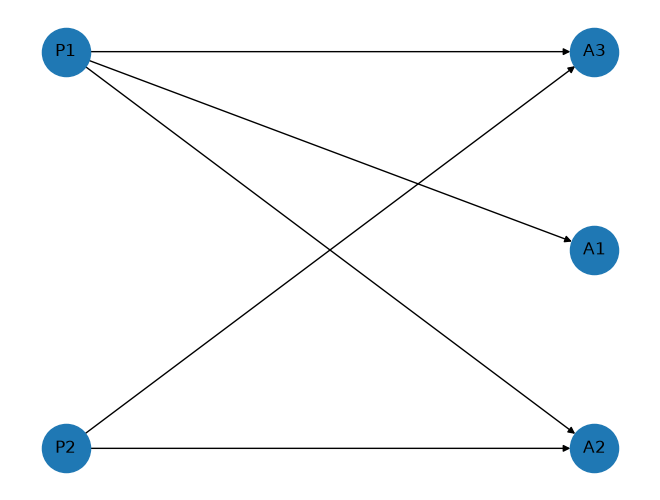

In [2]:
import matplotlib.pyplot as plt
pos = nx.bipartite_layout(G1, ['P1', 'P2'])
nx.draw(G1, pos, with_labels=True, node_size=1200)
plt.show()

# Primeiro caso conhecido: As sete pontes de Königsberg

## História
Aconteceu em Kaliningrado (nome dado em 1946) na Rússia, fica entre a Polônia e a Lituânia mas antigamente pertencia a Prússia. Esse território é dividido pelo Rio Pregel com 4 pedaços de terra.

![rio_pregel.png](assets/rio_pregel.png)
*Fonte: [Vídeo contando a história](https://www.youtube.com/watch?v=-Kznn0fprLc)*

Um dia, o prefeito do local desafiou os habitantes para encontrar um caminho que atravesse todas as sete pontes de uma única vez porém nenhuma ponte deve ser atravessada mais de uma vez. Euler pensou o seguinte:

### Como Euler resolveu?
Cada porção foi representada por um vértice (ou nó) e representou as relações de porção de terra por uma linha (ou seja, aresta), ou seja, a conexão das pontes. Quando Euler representou esse problema desse jeito, ele iniciou uma nova área da matemática, chamada de Teoria dos Grafos. Ele também introduziu um conceito chamado *grau de um vértice*, que é o número de arestas que tem naquele vértice. A ideia dele foi analisar se aquele vértice tem grau par ou ímpar. Toda vez que passamos por um vértice, usamos uma aresta para entrar e outra para sair. Por isso, os vértices intermediários do caminho precisam ter grau par. Só o ponto de partida e o de chegada podem ter grau ímpar. 

Euler então concluiu que, **se todos os vértices tiverem grau par, então o problema tem solução**. E também que, **contando os vértices de grau ímpar, Euler concluiu que o número de vértices de um grau ímpar deve ser 0 ou 2 (ele precisa ser o primeiro ou o último vértice da trajetória).** Ou seja, *para resolver o problema das sete pontes, Euler inferiu que ou todos os vértices tem que ter grau par ou apenas dois tem que ter grau ímpar e, os demais, par.*

> Se um grafo tiver um caminho Euleriano, então o número de vértices ímpar deve ser **zero** ou **dois**.

#### Visualizações pontes
##### 4 Pontes
![4_pontes.png](assets/4_pontes.png)
*Fonte: Autora*

Podemos verificar que, o caminho pode ser feito sem problemas, observando que todas as pontes são passadas e nenhuma é repetida. É um caminho Euleriano pois todas as arestas são visitadas. Vemos que todos os vértices tem grau = 2, ou seja, todos os graus são par. Ou seja, esse grafo segue a primeira condição proposta por Euler: "se todos os vértices tiverem grau par, então o problema tem solução", no grafo conexo.

##### 6 Pontes
![6_pontes.png](assets/6_pontes.png)
*Fonte: Autora*

Podemos verificar que, o caminho também pode ser feito sem problemas, observando que todas as pontes são passadas e nenhuma é repetida. É um caminho Euleriano pois todas as arestas são visitadas. Mas nem todos os vértices são de grau par, observe que (A = grau 3), (B = grau 4), (C = grau 3) e (D = grau 2) e mesmo assim conseguimos resolver o problema. Esse grafo satisfaz a segunda condição de Euler: "contando os vértices de grau ímpar, o número de vértices de um grau ímpar deve ser 0 ou 2".

#### 7 Pontes
![7_pontes.png](assets/7_pontes.png)
*Fonte: Autora*

Podemos verificar que, esse grafo não satisfaz nenhuma das duas condições de Euler. Dado que os graus dos vértices são: (A = grau 3), (B = grau 5), (C = grau 3) e (D = grau 3). Todos os graus são ímpares, logo o problema das 7 pontes é impossível.

### Caminho Euleriano 
Acontece quando é passado por cada aresta do grafo exatamente uma vez. Por exemplo, se fosse 6 pontes, teríamos um caminho Euleriano, pois todas as arestas do caminho de 6 pontes foram visitadas. Um caso especial é um Circuito Euleriano, um caminho Euleriano que começa e termina no mesmo vértice.
Grafos que possuem um circuito Euleriano são chamados de Grafos Eulerianos. Para ser chamado assim é preciso que todos os vértices sejam de **grau par**. Entretanto, é preciso também que o grafo seja conexo. 

![grafo-circuito-euleriano.png](assets/grafo-circuito-euleriano.png)
*Fonte: Wikipedia*


# Referências

- [Departamento de Matemática da Universidade de Coimbra - As pontes de Königsberg](https://www.mat.uc.pt/~alma/escolas/pontes/)
- [A história das sete pontes de Königsberg - Vídeo Youtube](https://youtu.be/-Kznn0fprLc?si=vClIIPEOe7PUk5he)
- [Wikipedia - Caminho Euleriano](https://pt.wikipedia.org/wiki/Caminho_euleriano)